In [1]:
import sys
sys.path.append('..')
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
import cartopy
import cartopy.crs as ccrs
import matplotlib.patches as patches
from src.inversion_scripts.utils import plot_field, sum_total_emissions, get_posterior_emissions, get_mean_emissions

In [2]:
state_vector_filepath = "/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2022_annual/StateVector.nc"

state_vector = xr.open_dataset(state_vector_filepath)
state_vector_labels = state_vector["StateVector"]

# Identify the last element of the region of interest
last_ROI_element = int(
    np.nanmax(state_vector_labels.values)
)

# Define mask for region of interest
mask = state_vector_labels <= last_ROI_element

In [3]:
def calc_emissions_within_region(lats, lons):
    '''Returns dataframe with absolute posterior emissions (Tg/yr) in each year for selected region'''

    # create dataframe to store emis_subset for each year
    df = pd.DataFrame(columns=["year", "emissions", "wetlands"])
    
    years = [2019, 2020, 2021, 2022, 2023, 2024]
    for year in years:
        # set directory
        if year == 2019:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
        else:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
        posterior_ds = xr.load_dataset(path)
        posterior = posterior_ds["EmisCH4_Total"]
        posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
        areas = posterior_ds["AREA"]

        # select grid cells only within lat and lon bounds in posterior
        posterior_subset = posterior.where((posterior.lat > lats[0]) 
                                    & (posterior.lat < lats[1]) 
                                    & (posterior.lon > lons[0]) 
                                    & (posterior.lon < lons[1]), drop=True)
        
        posterior_wetlands_subset = posterior_wetlands.where((posterior_wetlands.lat > lats[0]) 
                                    & (posterior_wetlands.lat < lats[1]) 
                                    & (posterior_wetlands.lon > lons[0]) 
                                    & (posterior_wetlands.lon < lons[1]), drop=True)
        
        # select grid cells only in lat and lon bounds in areas
        areas_subset = areas.where((areas.lat > lats[0])
                          & (areas.lat < lats[1]) 
                          & (areas.lon > lons[0]) 
                          & (areas.lon < lons[1]), drop=True)
        
        emis_subset = sum_total_emissions(posterior_subset, areas_subset, mask) # Tg/yr
        emis_wetlands_subset = sum_total_emissions(posterior_wetlands_subset, areas_subset, mask)
        df.loc[len(df)] = [year, emis_subset, emis_wetlands_subset]

    return df

In [4]:
def calc_emissions_at_gridcell(lat, lon):
    '''Returns dataframe with absolute posterior emissions (Tg/yr) in each year for selected grid cell'''

    ds_base = xr.open_dataset('/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2019_annual_ResMefix_2/inversion/posterior_ds.nc')
    sectors = [
        var
        for var in list(ds_base.keys())
        if "EmisCH4" in var and not ("Excl" in var or "Soil" in var or "Lakes" in var)
    ]

    rows = []
    years = [2019, 2020, 2021, 2022, 2023, 2024]

    for year in years:
        # set directory
        if year == 2019:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
        else:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
        posterior_ds = xr.open_dataset(path)
        areas = posterior_ds["AREA"]
        # select grid cells only in lat and lon bounds in areas
        areas_subset = areas.sel(lat=lat, lon=lon, method="nearest").item()

        row_data = {"year": year}
        
        for sector in sectors:
            # Grab the data for the current sector
            posterior = posterior_ds[sector]
            # Get the value at the grid cell
            posterior_subset = posterior.sel(lat=lat, lon=lon, method="nearest").item()
            # Calculate emissions (Tg/yr)
            emis_subset = posterior_subset * areas_subset * 86400 * 365 * 1e-9
            row_data[sector] = emis_subset

        rows.append(row_data)
    
    df = pd.DataFrame(rows)
    return df

   year  EmisCH4_Reservoirs  EmisCH4_Termites  EmisCH4_Seeps  \
0  2019            0.000000         -0.007917            0.0   
1  2020            0.302681          0.000700           -0.0   
2  2021            0.548082          0.001267            0.0   
3  2022            0.948541          0.002193            0.0   
4  2023            1.252896          0.002897            0.0   
5  2024            0.271432          0.000628            0.0   

   EmisCH4_Wetlands  EmisCH4_BiomassBurn  EmisCH4_OtherAnth  EmisCH4_Rice  \
0         -0.397048            -0.022623          -0.000058           0.0   
1          0.035097             0.002000           0.000005          -0.0   
2          0.063552             0.003621           0.000009           0.0   
3          0.109987             0.006267           0.000016           0.0   
4          0.145278             0.008278           0.000021           0.0   
5          0.031474             0.001793           0.000005           0.0   

   EmisCH4_

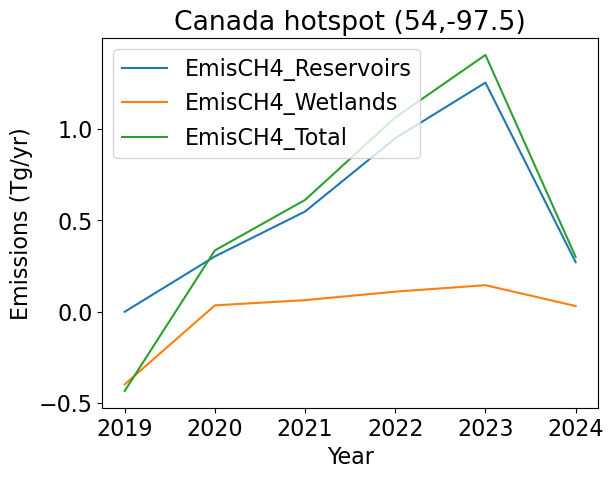

In [12]:
# Canada hotspot
canada = calc_emissions_at_gridcell(54,-97.5)
print(canada)
# plot EmisCH4_Reservoirs and EmisCH4_Wetlands
canada.plot(x="year", y=["EmisCH4_Reservoirs", "EmisCH4_Wetlands", "EmisCH4_Total"])
plt.title('Canada hotspot (54,-97.5)')
plt.xticks(canada["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.show()

   year  EmisCH4_Reservoirs  EmisCH4_Termites  EmisCH4_Seeps  \
0  2019           -0.256476               0.0            0.0   
1  2020           -0.603630               0.0            0.0   
2  2021           -1.428810               0.0            0.0   
3  2022           -1.846900               0.0            0.0   
4  2023           -1.864537               0.0            0.0   
5  2024           -1.153224               0.0            0.0   

   EmisCH4_Wetlands  EmisCH4_BiomassBurn  EmisCH4_OtherAnth  EmisCH4_Rice  \
0         -0.055899            -0.002317          -0.000026           0.0   
1         -0.131561            -0.005454          -0.000062           0.0   
2         -0.311409            -0.012910          -0.000148           0.0   
3         -0.402531            -0.016688          -0.000191           0.0   
4         -0.406376            -0.016848          -0.000193           0.0   
5         -0.251345            -0.010420          -0.000119           0.0   

   EmisCH4_

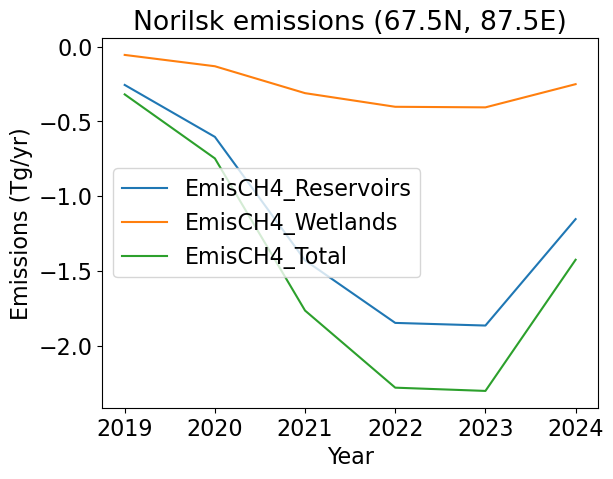

In [13]:
# Norilsk hotspot
norilsk = calc_emissions_at_gridcell(67.5,87.5)
print(norilsk)

norilsk.plot(x="year", y=["EmisCH4_Reservoirs", "EmisCH4_Wetlands", "EmisCH4_Total"])
plt.title('Norilsk emissions (67.5N, 87.5E)')
plt.xticks(norilsk["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.show()

   year  EmisCH4_Reservoirs  EmisCH4_Termites  EmisCH4_Seeps  \
0  2019                 0.0         -0.000434      -0.000245   
1  2020                 0.0         -0.000679      -0.000383   
2  2021                 0.0         -0.001510      -0.000853   
3  2022                 0.0         -0.003602      -0.002034   
4  2023                 0.0         -0.004870      -0.002750   
5  2024                 0.0         -0.007907      -0.004465   

   EmisCH4_Wetlands  EmisCH4_BiomassBurn  EmisCH4_OtherAnth  EmisCH4_Rice  \
0               0.0                  0.0          -0.000057           0.0   
1               0.0                  0.0          -0.000089           0.0   
2               0.0                  0.0          -0.000199           0.0   
3               0.0                  0.0          -0.000475           0.0   
4               0.0                  0.0          -0.000642           0.0   
5               0.0                  0.0          -0.001043           0.0   

   EmisCH4_

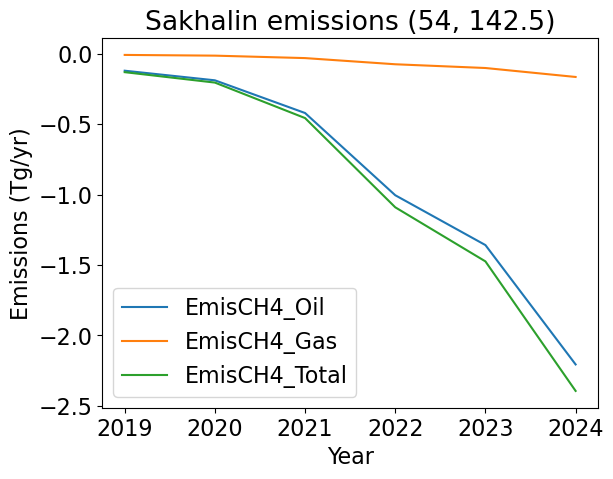

In [14]:
# Russia Sakhalin island
sakhalin = calc_emissions_at_gridcell(54,142.5)
print(sakhalin)

x = sakhalin["year"]
y = sakhalin["EmisCH4_Oil"] + sakhalin["EmisCH4_Gas"]
slope, _, _, p_value, _ = linregress(x, y)

print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

sakhalin.plot(x="year", y=["EmisCH4_Oil", "EmisCH4_Gas", "EmisCH4_Total"])
plt.title('Sakhalin emissions (54, 142.5)')
plt.xticks(sakhalin["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.show()

In [ ]:
# South America
brazil_1 = calc_emissions_at_gridcell(-4, -50) # reservoirs, wetlands, livestock
brazil_2 = calc_emissions_at_gridcell(-4, -60) # wetlands, livestock
pantanal = calc_emissions_at_gridcell(-18, -55) # wetlands, livestock
venezuela = calc_emissions_at_gridcell(10, -62.5) # wetlands, biomassburn, waste, landfills, livestock, gas, oil
colombia = calc_emissions_at_gridcell(10, -75)

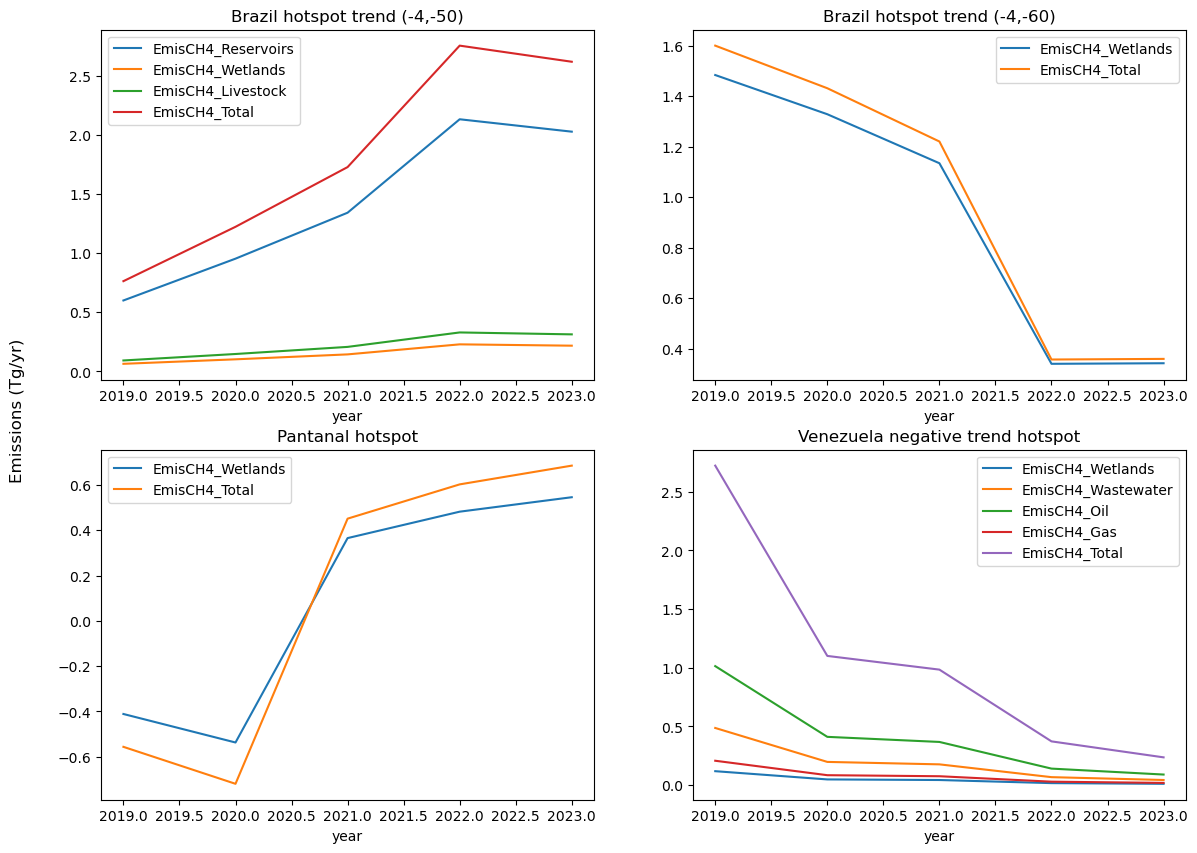

In [30]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
brazil_1.plot(x="year", y=["EmisCH4_Reservoirs", "EmisCH4_Wetlands", "EmisCH4_Livestock", "EmisCH4_Total"], ax=axs[0, 0])
axs[0, 0].set_title("Brazil hotspot trend (-4,-50)")

brazil_2.plot(x="year", y=["EmisCH4_Wetlands", "EmisCH4_Total"], ax=axs[0, 1])
axs[0, 1].set_title("Brazil hotspot trend (-4,-60)")

pantanal.plot(x="year", y=["EmisCH4_Wetlands", "EmisCH4_Total"], ax=axs[1, 0])
axs[1, 0].set_title("Pantanal hotspot")

venezuela.plot(x="year", y=["EmisCH4_Wetlands", "EmisCH4_Wastewater", "EmisCH4_Oil", "EmisCH4_Gas", "EmisCH4_Total"], ax=axs[1, 1])
axs[1, 1].set_title("Venezuela negative trend hotspot")

fig.text(0.06, 0.5, 'Emissions (Tg/yr)', va='center', rotation='vertical', fontsize=12)

plt.show()

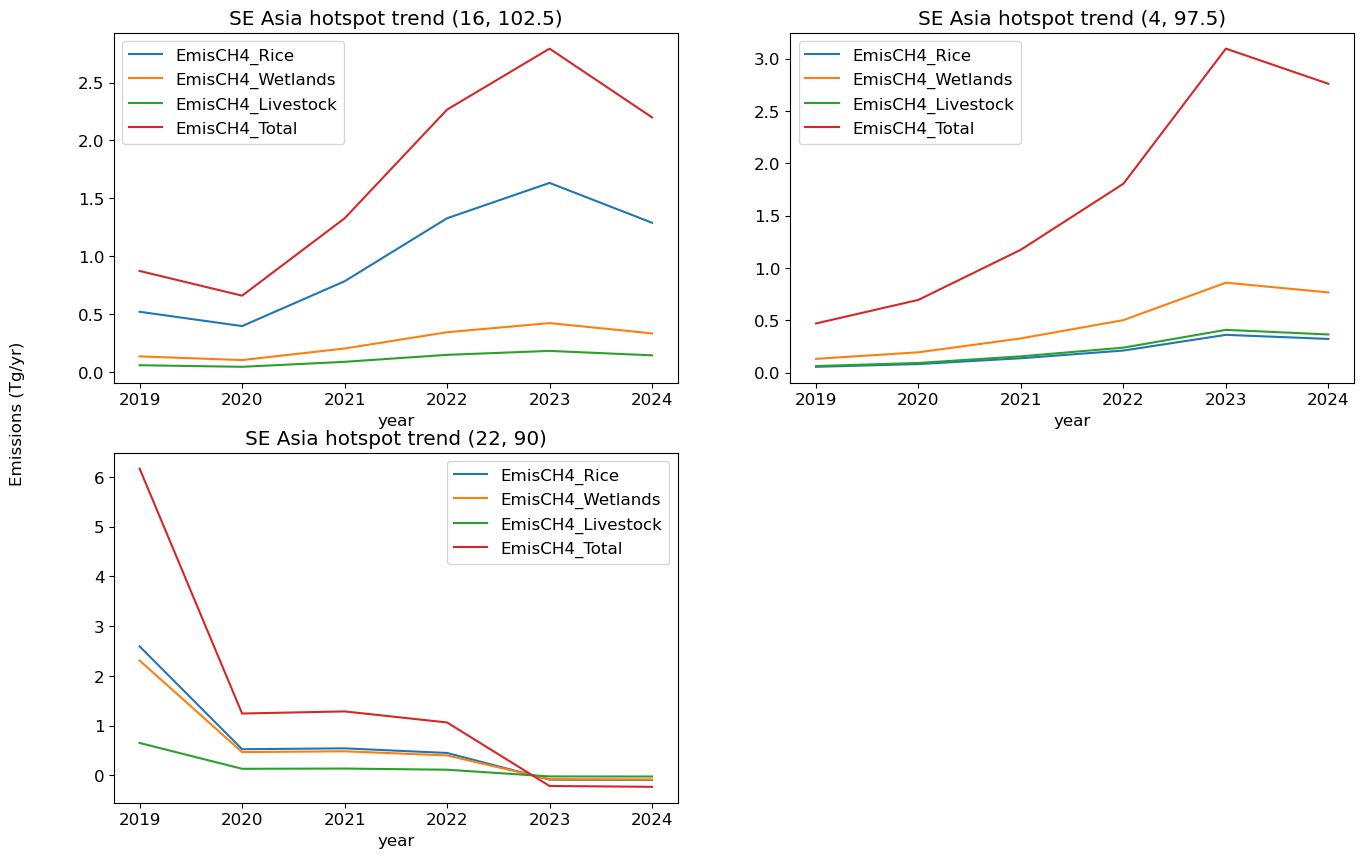

In [24]:
# SE Asia
se_asia_1 = calc_emissions_at_gridcell(16, 102.5)
se_asia_2 = calc_emissions_at_gridcell(4, 97.5)
se_asia_3 = calc_emissions_at_gridcell(22, 90)

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
plt.rcParams.update({'font.size': 12})
se_asia_1.plot(x="year", y=["EmisCH4_Rice", "EmisCH4_Wetlands", "EmisCH4_Livestock", "EmisCH4_Total"], ax=axs[0, 0])
axs[0, 0].set_title("SE Asia hotspot trend (16, 102.5)")

se_asia_2.plot(x="year", y=["EmisCH4_Rice", "EmisCH4_Wetlands", "EmisCH4_Livestock", "EmisCH4_Total"], ax=axs[0, 1])
axs[0, 1].set_title("SE Asia hotspot trend (4, 97.5)")

se_asia_3.plot(x="year", y=["EmisCH4_Rice", "EmisCH4_Wetlands", "EmisCH4_Livestock", "EmisCH4_Total"], ax=axs[1, 0])
axs[1, 0].set_title("SE Asia hotspot trend (22, 90)")

axs[1, 1].remove()

fig.text(0.06, 0.5, 'Emissions (Tg/yr)', va='center', rotation='vertical', fontsize=12)

plt.show()

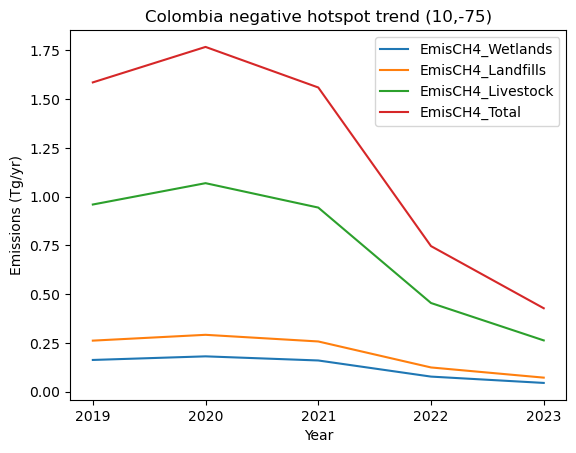

In [28]:
colombia.plot(x="year", y=["EmisCH4_Wetlands", "EmisCH4_Landfills", "EmisCH4_Livestock", "EmisCH4_Total"])
plt.title('Colombia negative hotspot trend (10,-75)')
plt.xticks(colombia["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.show()

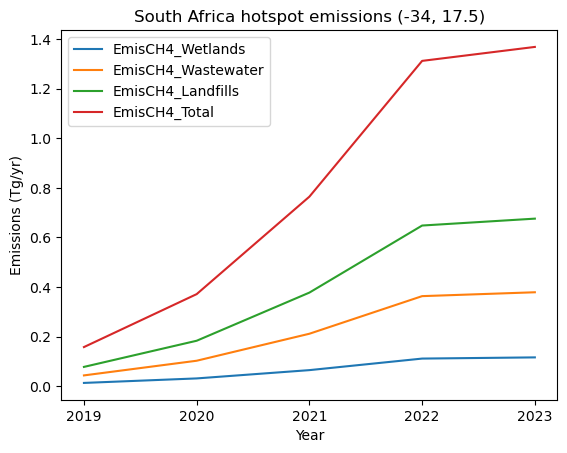

In [20]:
south_africa = calc_emissions_at_gridcell(-34, 17.5)
south_africa.plot(x="year", y=["EmisCH4_Wetlands", "EmisCH4_Wastewater", "EmisCH4_Landfills", "EmisCH4_Total"])
plt.title('South Africa hotspot emissions (-34, 17.5)')
plt.xticks(south_africa["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.show()

In [7]:
# Sudd
lat_bounds_sudd = [5, 10]
lon_bounds_sudd = [28, 34.5]
sudd = calc_emissions_within_region(lat_bounds_sudd, lon_bounds_sudd)
print(sudd)

x = sudd["year"]
y = sudd["emissions"]
y1 = sudd["wetlands"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)

print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")
print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

     year  emissions  wetlands
0  2019.0   1.634386  1.136718
1  2020.0   2.081633  1.388158
2  2021.0   2.971119  1.930155
3  2022.0   4.608237  2.966113
4  2023.0   2.426838  1.580098
5  2024.0   2.657352  1.718707
Slope (annual change in total emissions): 0.22 Tg/yr
P-value: 0.4268
Slope (annual change in wetland emissions): 0.13 Tg/yr
P-value: 0.4595


In [5]:
# Congo basin
lat_bounds_congo = [-10, 5]
lon_bounds_congo = [15, 30]
congo = calc_emissions_within_region(lat_bounds_congo, lon_bounds_congo)
print(congo)

x = congo["year"]
y = congo["emissions"]
y1 = congo["wetlands"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)

print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")
print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

     year  emissions  wetlands
0  2019.0   6.931426  6.024360
1  2020.0   7.588026  6.556825
2  2021.0   7.606447  6.607431
3  2022.0   5.401621  4.593150
4  2023.0   5.530940  4.667892
5  2024.0   4.713054  3.772566
Slope (annual change in total emissions): -0.56 Tg/yr
P-value: 0.0365
Slope (annual change in wetland emissions): -0.54 Tg/yr
P-value: 0.0302


In [5]:
# Japan
lat_bounds_japan = [30, 45]
lon_bounds_japan = [130, 145]

japan = calc_emissions_within_region(lat_bounds_japan, lon_bounds_japan)
print(japan)

x = japan["year"]
y = japan["emissions"]
slope, _, _, p_value, _ = linregress(x, y)

print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f'2019-2024 posterior emissions mean: {y.mean():.2f} Tg/yr')

     year  emissions  wetlands
0  2019.0   5.566532  2.265572
1  2020.0   3.764407  1.520990
2  2021.0   5.865058  2.602286
3  2022.0   2.881999  1.191656
4  2023.0   3.357221  1.351699
5  2024.0   3.220128  1.170076
Slope (annual change in total emissions): -0.46 Tg/yr
P-value: 0.1490
2019-2024 posterior emissions mean: 4.11 Tg/yr


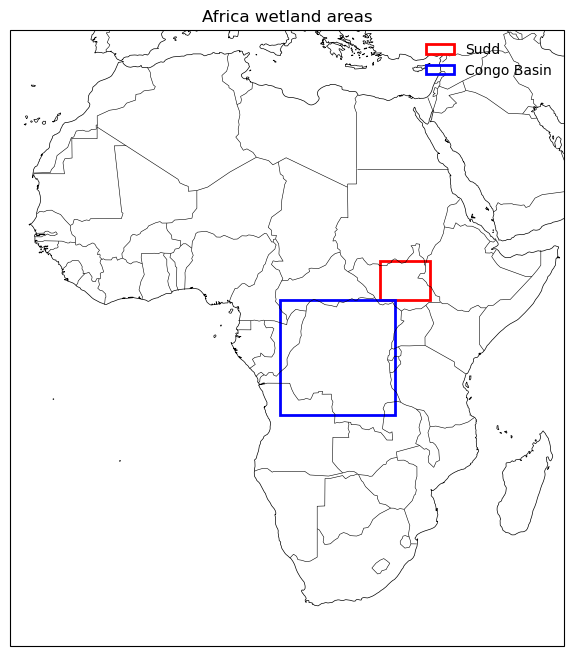

In [8]:
# draw box around region in a plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.4)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.5)

width_sudd = lon_bounds_sudd[1] - lon_bounds_sudd[0]
height_sudd = lat_bounds_sudd[1] - lat_bounds_sudd[0]

width_congo = lon_bounds_congo[1] - lon_bounds_congo[0]
height_congo = lat_bounds_congo[1] - lat_bounds_congo[0]

# create a rectangular patch
rect_sudd = patches.Rectangle((lon_bounds_sudd[0], lat_bounds_sudd[0]), width_sudd, height_sudd,
                         linewidth=2, edgecolor='red', facecolor='none', label='Sudd',
                         transform=ccrs.PlateCarree())

rect_congo = patches.Rectangle((lon_bounds_congo[0], lat_bounds_congo[0]), width_congo, height_congo,
                         linewidth=2, edgecolor='blue', facecolor='none', label='Congo Basin',
                         transform=ccrs.PlateCarree())

ax.add_patch(rect_sudd)
ax.add_patch(rect_congo)

ax.set_extent([-20, 52, -40, 40], crs=ccrs.PlateCarree())
ax.set_title("Africa wetland areas")
ax.legend(frameon=False)

plt.show()

In [5]:
# China livestock
df = pd.DataFrame(columns=["year", "emissions"])
mask_china = xr.open_dataset("../shapefiles/masks/china.nc")
mask_china = mask_china.rename({"__xarray_dataarray_variable__": "Mask"})
mask_china = mask_china["Mask"]
years = [2019, 2020, 2021, 2022, 2023]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Livestock"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_china) # Tg/yr
    df.loc[len(df)] = [year, emis_subset]

print(df)

x = df["year"]
y = df["emissions"]
slope, _, _, p_value, _ = linregress(x, y)

# Print the regression results.
print(f"Slope (annual change in livestock emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

     year  emissions
0  2019.0   8.421785
1  2020.0   8.892949
2  2021.0   8.655594
3  2022.0   7.981481
4  2023.0   8.504044
Slope (annual change in livestock emissions): -0.07 Tg/yr
P-value: 0.5626


In [9]:
# Congo basin
df = pd.DataFrame(columns=["year", "emissions", "wetlands"])
mask_congo = xr.open_dataset("../shapefiles/masks/congo_basin.nc")
mask_congo = mask_congo.rename({"__xarray_dataarray_variable__": "Mask"})
mask_congo = mask_congo["Mask"]
years = [2019, 2020, 2021, 2022, 2023]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_congo) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_congo) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)

# Print the regression results.
print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

     year  emissions   wetlands
0  2019.0  12.349500   9.647814
1  2020.0  13.919003  10.419850
2  2021.0  15.059441  10.763739
3  2022.0  10.689003   7.441537
4  2023.0  11.402982   7.635158
Slope (annual change in total emissions): -0.51 Tg/yr
P-value: 0.4458
Slope (annual change in wetland emissions): -0.70 Tg/yr
P-value: 0.1772


In [5]:
# East Africa
df = pd.DataFrame(columns=["year", "emissions", "wetlands", "livestock"])
mask_eastafrica = xr.open_dataset("../shapefiles/masks/east_africa.nc")
mask_eastafrica = mask_eastafrica.rename({"__xarray_dataarray_variable__": "Mask"})
mask_eastafrica = mask_eastafrica["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_eastafrica) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_eastafrica) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_eastafrica) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands, emis_subset_livestock]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
y2 = df["livestock"]
slope, _, _, p_value, std_error = linregress(x, y)
slope1, _, _, p_value1, std_error1 = linregress(x, y1)
slope2, _, _, p_value2, std_error2 = linregress(x, y2)

# Print the regression results.
print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}, std error: {std_error:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}, std error: {std_error1:.4f}")

print(f"Slope (annual change in livestock emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}, std error: {std_error2:.4f}")

     year  emissions  wetlands  livestock
0  2019.0  18.710099  5.983798   6.694396
1  2020.0  24.281987  7.702226   8.824224
2  2021.0  25.665075  8.145229   9.043324
3  2022.0  23.943361  6.967351   8.771047
4  2023.0  27.039351  7.802604   9.972146
5  2024.0  27.541906  8.013507  10.204522
Slope (annual change in total emissions): 1.45 Tg/yr
P-value: 0.0324, std error: 0.4504
Slope (annual change in wetland emissions): 0.26 Tg/yr
P-value: 0.2045, std error: 0.1749
Slope (annual change in livestock emissions): 0.59 Tg/yr
P-value: 0.0177, std error: 0.1522


In [2]:
# East Africa
df = pd.DataFrame(columns=["year", "emissions", "wetlands", "livestock"])
mask_SA = xr.open_dataset("../shapefiles/masks/SA.nc")
mask_SA = mask_SA.rename({"__xarray_dataarray_variable__": "Mask"})
mask_SA = mask_SA["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_SA) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_SA) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_SA) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands, emis_subset_livestock]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
y2 = df["livestock"]
slope, _, _, p_value, std_error = linregress(x, y)
slope1, _, _, p_value1, std_error1 = linregress(x, y1)
slope2, _, _, p_value2, std_error2 = linregress(x, y2)

# Print the regression results.
print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}, std error: {std_error:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}, std error: {std_error1:.4f}")

print(f"Slope (annual change in livestock emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}, std error: {std_error2:.4f}")

     year  emissions   wetlands  livestock
0  2019.0  94.664844  51.925318  21.872020
1  2020.0  87.037512  41.473343  24.008820
2  2021.0  96.155639  44.179589  26.123419
3  2022.0  99.084400  42.186506  27.898019
4  2023.0  93.688709  41.410125  27.185895
5  2024.0  99.241703  40.778335  29.823516
Slope (annual change in total emissions): 1.31 Tg/yr
P-value: 0.2649, std error: 1.0094
Slope (annual change in wetland emissions): -1.65 Tg/yr
P-value: 0.0966, std error: 0.7652
Slope (annual change in livestock emissions): 1.46 Tg/yr
P-value: 0.0025, std error: 0.2158


In [6]:
# Central Africa
df = pd.DataFrame(columns=["year", "emissions", "wetlands", "livestock"])
mask_centralafrica = xr.open_dataset("../shapefiles/masks/central_africa.nc")
mask_centralafrica = mask_centralafrica.rename({"__xarray_dataarray_variable__": "Mask"})
mask_centralafrica = mask_centralafrica["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_centralafrica) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_centralafrica) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_centralafrica) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands, emis_subset_livestock]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
y2 = df["livestock"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)

# Print the regression results.
print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in livestock emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

     year  emissions   wetlands  livestock
0  2019.0  17.290381  10.661942   3.070207
1  2020.0  19.476798  11.590037   3.718486
2  2021.0  20.102346  11.982238   3.497450
3  2022.0  16.772987   9.124667   3.520667
4  2023.0  18.610611   9.420835   4.395799
5  2024.0  17.725611   8.012320   4.720770
Slope (annual change in total emissions): -0.11 Tg/yr
P-value: 0.7698
Slope (annual change in wetland emissions): -0.65 Tg/yr
P-value: 0.0642
Slope (annual change in livestock emissions): 0.29 Tg/yr
P-value: 0.0170


In [6]:
# Amazon basin
df = pd.DataFrame(columns=["year", "emissions"])
mask_amazon = xr.open_dataset("../shapefiles/masks/amazon.nc")
mask_amazon = mask_amazon.rename({"__xarray_dataarray_variable__": "Mask"})
mask_amazon = mask_amazon["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_amazon) # Tg/yr
    df.loc[len(df)] = [year, emis_subset]

print(df)

x = df["year"]
y = df["emissions"]
slope, _, _, p_value, _ = linregress(x, y)

# Print the regression results.
print(f"Slope (annual change in wetland emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

     year  emissions
0  2019.0  39.406802
1  2020.0  29.665576
2  2021.0  29.925845
3  2022.0  26.880253
4  2023.0  26.136354
5  2024.0  23.068940
Slope (annual change in wetland emissions): -2.72 Tg/yr
P-value: 0.0122


In [13]:
# Hudson Bay Lowlands
df = pd.DataFrame(columns=["year", "emissions"])
mask_hbl = xr.open_dataset("../shapefiles/masks/hbl.nc")
mask_hbl = mask_hbl.rename({"__xarray_dataarray_variable__": "Mask"})
mask_hbl = mask_hbl["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_hbl) # Tg/yr
    df.loc[len(df)] = [year, emis_subset]

print(df)

x = df["year"]
y = df["emissions"]
slope, _, _, p_value, _ = linregress(x, y)

# Print the regression results.
print(f"Slope (annual change in wetland emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

     year  emissions
0  2019.0   1.574435
1  2020.0   1.449308
2  2021.0   1.170325
3  2022.0   0.772723
4  2023.0   0.719736
5  2024.0   0.925904
Slope (annual change in wetland emissions): -0.17 Tg/yr
P-value: 0.0225


In [6]:
# Hudson Bay Lowlands gridbox (Pickett Heaps et al 2011)
lat_bounds_hbl = [50, 60]
lon_bounds_hbl = [-96, -75]
hbl = calc_emissions_within_region(lat_bounds_hbl, lon_bounds_hbl)
print(hbl)

x = hbl["year"]
y = hbl["emissions"]
y1 = hbl["wetlands"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)

print(f'mean total emissions: {np.mean(y):.2f}')
print(f'mean wetland emissions: {np.mean(y1):.2f}')

print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")
print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

     year  emissions  wetlands
0  2019.0   2.882140  2.775484
1  2020.0   3.006583  2.778159
2  2021.0   2.703136  2.539377
3  2022.0   2.029231  1.941607
4  2023.0   1.440951  1.523337
5  2024.0   1.871472  1.938103
mean total emissions: 2.32
mean wetland emissions: 2.25
Slope (annual change in total emissions): -0.30 Tg/yr
P-value: 0.0199
Slope (annual change in wetland emissions): -0.24 Tg/yr
P-value: 0.0220


In [14]:
# West Siberian Lowlands
df = pd.DataFrame(columns=["year", "emissions"])
mask_wsl = xr.open_dataset("../shapefiles/masks/wsl.nc")
mask_wsl = mask_wsl.rename({"__xarray_dataarray_variable__": "Mask"})
mask_wsl = mask_wsl["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_wsl) # Tg/yr
    df.loc[len(df)] = [year, emis_subset]

print(df)

x = df["year"]
y = df["emissions"]
slope, _, _, p_value, _ = linregress(x, y)

# Print the regression results.
print(f"Slope (annual change in wetland emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

     year  emissions
0  2019.0  10.805059
1  2020.0   9.512858
2  2021.0   9.372958
3  2022.0   9.468200
4  2023.0   7.085936
5  2024.0   9.789580
Slope (annual change in wetland emissions): -0.35 Tg/yr
P-value: 0.2730


In [7]:
# Pantanal
df = pd.DataFrame(columns=["year", "emissions", "wetlands"])
mask_pantanal = xr.open_dataset("../shapefiles/masks/pantanal.nc")
mask_pantanal = mask_pantanal.rename({"__xarray_dataarray_variable__": "Mask"})
mask_pantanal = mask_pantanal["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_pantanal) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_pantanal) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)

# Print the regression results.
print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")
print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

     year  emissions  wetlands
0  2019.0  -0.626479 -0.453566
1  2020.0  -0.832286 -0.613442
2  2021.0   0.342325  0.278667
3  2022.0   0.500594  0.403321
4  2023.0   0.617822  0.491999
5  2024.0   0.123028  0.109483
Slope (annual change in total emissions): 0.24 Tg/yr
P-value: 0.1023
Slope (annual change in wetland emissions): 0.18 Tg/yr
P-value: 0.1042


In [25]:
# Southeast Asia
df = pd.DataFrame(columns=["year", "emissions", "wetlands", "livestock", "rice", "waste"])
mask_se_asia = xr.open_dataset("../shapefiles/masks/southeast-asia.nc")
mask_se_asia = mask_se_asia.rename({"__xarray_dataarray_variable__": "Mask"})
mask_se_asia = mask_se_asia["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_rice = posterior_ds["EmisCH4_Rice"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"] + posterior_ds["EmisCH4_Landfills"] + posterior_ds["EmisCH4_OtherAnth"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_se_asia) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_se_asia) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_se_asia) # Tg/yr
    emis_subset_rice = sum_total_emissions(posterior_rice, areas, mask_se_asia) # Tg/yr
    emis_subset_waste = sum_total_emissions(posterior_waste, areas, mask_se_asia) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands, emis_subset_livestock, emis_subset_rice, emis_subset_waste]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
y2 = df["livestock"]
y3 = df["rice"]
y4 = df["waste"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)
slope4, _, _, p_value4, _ = linregress(x, y4)

# Print the regression results.
print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in livestock emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

print(f"Slope (annual change in rice emissions): {slope3:.2f} Tg/yr")
print(f"P-value: {p_value3:.4f}")

print(f"Slope (annual change in waste emissions): {slope4:.2f} Tg/yr")
print(f"P-value: {p_value4:.4f}")

     year  emissions   wetlands  livestock      rice     waste
0  2019.0  38.865433  16.675413   3.808915  8.025071  5.546189
1  2020.0  34.645878  17.452026   3.177359  4.303526  4.757796
2  2021.0  36.501773  16.381708   3.694216  5.429213  5.733070
3  2022.0  38.688648  17.057254   3.988937  6.042433  6.413464
4  2023.0  40.293422  17.199208   4.118254  6.557877  6.667246
5  2024.0  39.099639  16.483132   4.031581  6.439570  6.375418
Slope (annual change in total emissions): 0.58 Tg/yr
P-value: 0.2825
Slope (annual change in wetland emissions): -0.03 Tg/yr
P-value: 0.8046
Slope (annual change in livestock emissions): 0.12 Tg/yr
P-value: 0.1549
Slope (annual change in rice emissions): -0.02 Tg/yr
P-value: 0.9644
Slope (annual change in waste emissions): 0.30 Tg/yr
P-value: 0.0602


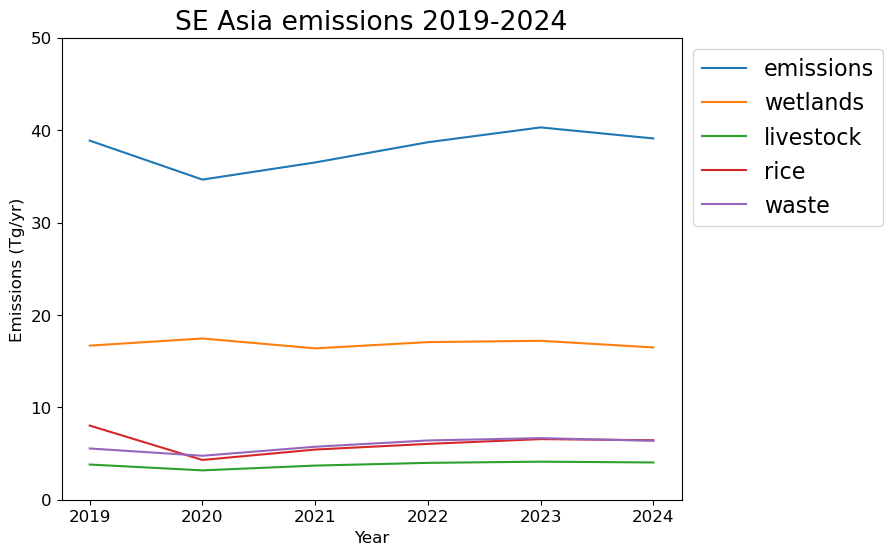

In [26]:
# plot df
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
df.plot(x="year", y=["emissions", "wetlands", "livestock", "rice", "waste"], ax=ax)
plt.xticks(df["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.ylim(0,50)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('SE Asia emissions 2019-2024')
plt.show()

In [5]:
# South Asia
df = pd.DataFrame(columns=["year", "emissions", "wetlands", "livestock", "rice", "waste"])
mask_south_asia = xr.open_dataset("../shapefiles/masks/south-asia.nc")
mask_south_asia = mask_south_asia.rename({"__xarray_dataarray_variable__": "Mask"})
mask_south_asia = mask_south_asia["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_rice = posterior_ds["EmisCH4_Rice"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"] + posterior_ds["EmisCH4_Landfills"] + posterior_ds["EmisCH4_OtherAnth"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_south_asia) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_south_asia) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_south_asia) # Tg/yr
    emis_subset_rice = sum_total_emissions(posterior_rice, areas, mask_south_asia) # Tg/yr
    emis_subset_waste = sum_total_emissions(posterior_waste, areas, mask_south_asia) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands, emis_subset_livestock, emis_subset_rice, emis_subset_waste]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
y2 = df["livestock"]
y3 = df["rice"]
y4 = df["waste"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)
slope4, _, _, p_value4, _ = linregress(x, y4)

# Print the regression results.
print(f"Slope (annual change in total emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in livestock emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

print(f"Slope (annual change in rice emissions): {slope3:.2f} Tg/yr")
print(f"P-value: {p_value3:.4f}")

print(f"Slope (annual change in waste emissions): {slope4:.2f} Tg/yr")
print(f"P-value: {p_value4:.4f}")

     year  emissions   wetlands  livestock      rice     waste
0  2019.0  47.466100  10.014827  17.052336  9.428799  9.224184
1  2020.0  43.586416   8.115302  16.879313  8.225233  8.876582
2  2021.0  42.471374   7.413564  16.468918  8.117275  8.869531
3  2022.0  41.147236   7.360363  16.181698  7.378241  8.521241
4  2023.0  41.812423   7.088897  16.868791  7.203082  8.862482
5  2024.0  43.758745   6.965953  18.402884  6.965288  9.297828
Slope (annual change in total emissions): -0.72 Tg/yr
P-value: 0.2078
Slope (annual change in wetland emissions): -0.53 Tg/yr
P-value: 0.0286
Slope (annual change in livestock emissions): 0.18 Tg/yr
P-value: 0.3733
Slope (annual change in rice emissions): -0.46 Tg/yr
P-value: 0.0038
Slope (annual change in waste emissions): -0.00 Tg/yr
P-value: 0.9937


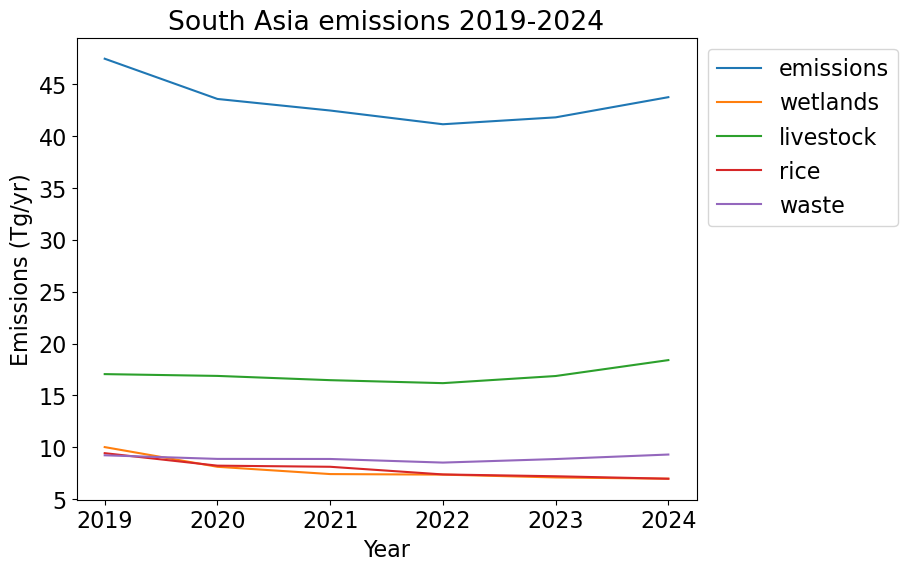

In [7]:
# plot df
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
df.plot(x="year", y=["emissions", "wetlands", "livestock", "rice", "waste"], ax=ax)
plt.xticks(df["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
# plt.ylim(0,50)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('South Asia emissions 2019-2024')
plt.show()

In [5]:
# Colombia total emissions
df = pd.DataFrame(columns=["year", "emissions", "wetlands", "livestock", "waste", "coal", "OG"])
mask_colombia = xr.open_dataset("../shapefiles/masks/colombia.nc")
mask_colombia = mask_colombia.rename({"__xarray_dataarray_variable__": "Mask"})
mask_colombia = mask_colombia["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"]+posterior_ds["EmisCH4_Landfills"]+posterior_ds["EmisCH4_OtherAnth"]
    posterior_coal = posterior_ds["EmisCH4_Coal"]
    posterior_og = posterior_ds["EmisCH4_Oil"] + posterior_ds["EmisCH4_Gas"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_colombia) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_colombia) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_colombia) # Tg/yr
    emis_subset_waste = sum_total_emissions(posterior_waste, areas, mask_colombia) # Tg/yr
    emis_subset_coal = sum_total_emissions(posterior_coal, areas, mask_colombia) # Tg/yr
    emis_subset_og = sum_total_emissions(posterior_og, areas, mask_colombia) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands, emis_subset_livestock, emis_subset_waste, emis_subset_coal, emis_subset_og]
print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
y2 = df["livestock"]
y3 = df["waste"]
y4 = df["coal"]
y5 = df["OG"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)
slope5, _, _, p_value5, _ = linregress(x, y5)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in livestock emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

print(f"Slope (annual change in waste emissions): {slope3:.2f} Tg/yr")
print(f"P-value: {p_value3:.4f}")

print(f"Slope (annual change in OG emissions): {slope5:.2f} Tg/yr")
print(f"P-value: {p_value5:.4f}")

     year  emissions  wetlands  livestock     waste      coal        OG
0  2019.0  11.816120  7.813544   2.327194  0.973257  0.328239  0.273030
1  2020.0  11.857442  6.635269   2.943663  1.251547  0.473599  0.385240
2  2021.0  13.402620  6.663602   3.617012  1.569632  0.693187  0.558555
3  2022.0  14.111326  7.255993   3.553807  1.476490  0.815623  0.641998
4  2023.0  12.871830  5.738474   3.574293  1.599455  0.890776  0.700135
5  2024.0  12.340251  6.167131   3.169122  1.404492  0.694594  0.609080
Slope (annual change in emissions): 0.18 Tg/yr
P-value: 0.4641
Slope (annual change in wetland emissions): -0.30 Tg/yr
P-value: 0.0907
Slope (annual change in livestock emissions): 0.17 Tg/yr
P-value: 0.1702
Slope (annual change in waste emissions): 0.09 Tg/yr
P-value: 0.1163
Slope (annual change in OG emissions): 0.08 Tg/yr
P-value: 0.0210


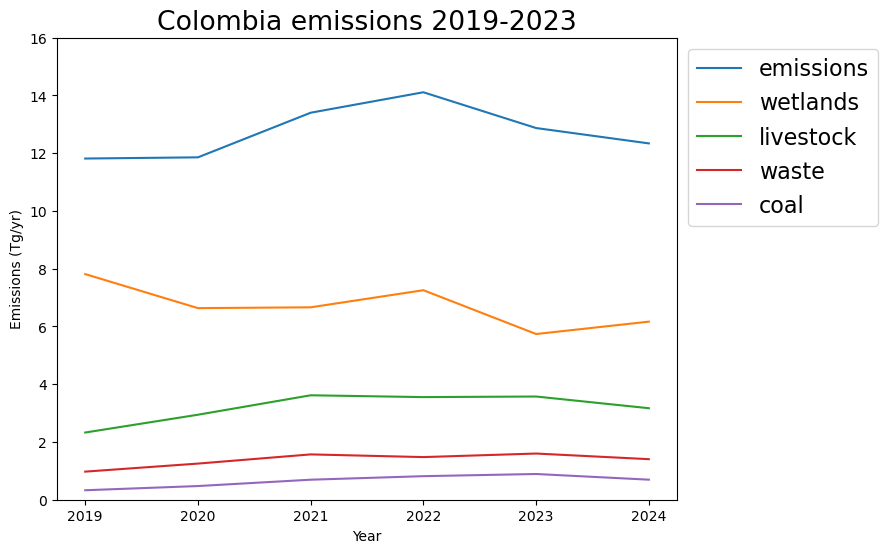

In [6]:
# plot df
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
df.plot(x="year", y=["emissions", "wetlands", "livestock", "waste", "coal"], ax=ax)
plt.xticks(df["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.ylim(0,16)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Colombia emissions 2019-2023')
plt.show()

In [7]:
# Brazil total emissions
df = pd.DataFrame(columns=["year", "emissions", "wetlands", "livestock", "waste", "coal"])
mask_brazil = xr.open_dataset("../shapefiles/masks/brazil.nc")
mask_brazil = mask_brazil.rename({"__xarray_dataarray_variable__": "Mask"})
mask_brazil = mask_brazil["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"]+posterior_ds["EmisCH4_Landfills"]+posterior_ds["EmisCH4_OtherAnth"]
    posterior_coal = posterior_ds["EmisCH4_Coal"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_brazil) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_brazil) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_brazil) # Tg/yr
    emis_subset_waste = sum_total_emissions(posterior_waste, areas, mask_brazil) # Tg/yr
    emis_subset_coal = sum_total_emissions(posterior_coal, areas, mask_brazil) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands, emis_subset_livestock, emis_subset_waste, emis_subset_coal]
print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
y2 = df["livestock"]
y3 = df["waste"]
y4 = df["coal"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in livestock emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

print(f"Slope (annual change in waste emissions): {slope3:.2f} Tg/yr")
print(f"P-value: {p_value3:.4f}")

     year  emissions   wetlands  livestock     waste      coal
0  2019.0  56.598974  37.139969  11.377415  4.650740  0.018594
1  2020.0  51.301840  29.950234  12.539917  4.985565  0.011119
2  2021.0  54.062608  32.219726  12.551344  5.042638  0.011862
3  2022.0  55.111902  28.750610  14.634030  6.027374  0.013833
4  2023.0  55.676276  29.893347  14.534926  5.717588  0.013108
5  2024.0  51.467478  24.809891  15.546243  5.497435  0.013011
Slope (annual change in emissions): -0.33 Tg/yr
P-value: 0.5946
Slope (annual change in wetland emissions): -1.87 Tg/yr
P-value: 0.0297
Slope (annual change in livestock emissions): 0.83 Tg/yr
P-value: 0.0020
Slope (annual change in waste emissions): 0.21 Tg/yr
P-value: 0.0736


In [9]:
# Europe total emissions
df = pd.DataFrame(columns=["year", "emissions", "livestock", "waste", "oil/gas"])
mask_europe = xr.open_dataset("../shapefiles/masks/europe.nc")
mask_europe = mask_europe.rename({"__xarray_dataarray_variable__": "Mask"})
mask_europe = mask_europe["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"]+posterior_ds["EmisCH4_Landfills"]+posterior_ds["EmisCH4_OtherAnth"]
    posterior_og = posterior_ds["EmisCH4_Oil"] + posterior_ds["EmisCH4_Gas"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_europe) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_europe) # Tg/yr
    emis_subset_waste = sum_total_emissions(posterior_waste, areas, mask_europe) # Tg/yr
    emis_subset_og = sum_total_emissions(posterior_og, areas, mask_europe) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_livestock, emis_subset_waste, emis_subset_og]
print(df)

x = df["year"]
y = df["emissions"]
y1 = df["livestock"]
y2 = df["waste"]
y3 = df["oil/gas"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in livestock emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in waste emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

print(f"Slope (annual change in og emissions): {slope3:.2f} Tg/yr")
print(f"P-value: {p_value3:.4f}")

     year  emissions  livestock     waste   oil/gas
0  2019.0  17.873639   7.526558  6.075071  2.059003
1  2020.0  22.051075   8.265457  6.570142  2.155963
2  2021.0  21.527042   8.792156  6.819405  2.134034
3  2022.0  19.833634   8.306527  6.386923  1.949983
4  2023.0  24.322570  10.983249  7.382634  2.221557
5  2024.0  24.671479  11.459083  7.419454  2.263297
Slope (annual change in emissions): 1.12 Tg/yr
P-value: 0.0550
Slope (annual change in livestock emissions): 0.78 Tg/yr
P-value: 0.0121
Slope (annual change in waste emissions): 0.25 Tg/yr
P-value: 0.0278
Slope (annual change in og emissions): 0.03 Tg/yr
P-value: 0.3266


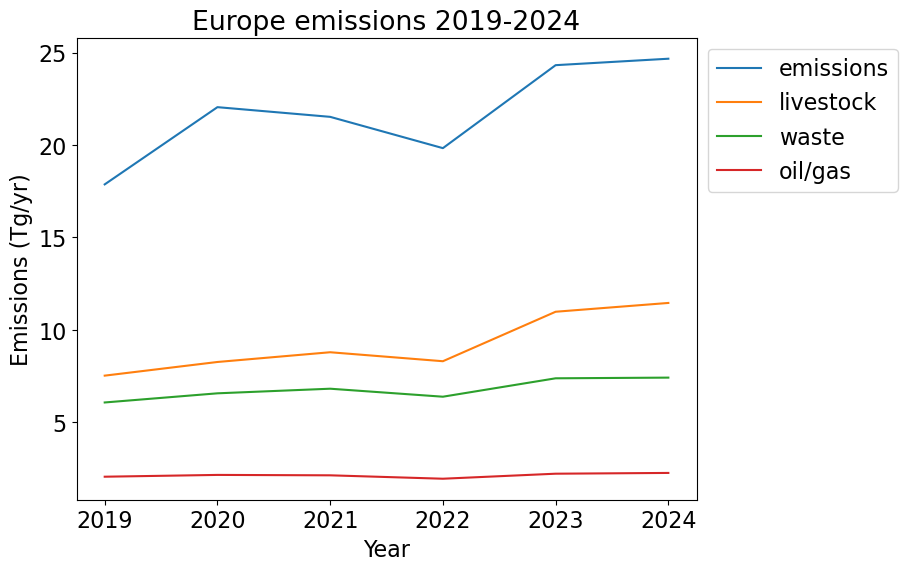

In [11]:
# plot df
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
df.plot(x="year", y=["emissions", "livestock", "waste", "oil/gas"], ax=ax)
plt.xticks(df["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Europe emissions 2019-2024')
plt.show()

   year  EmisCH4_Reservoirs  EmisCH4_Termites  EmisCH4_Seeps  \
0  2019                 0.0          0.001042       0.000341   
1  2020                 0.0          0.002107       0.000690   
2  2021                 0.0          0.002298       0.000752   
3  2022                 0.0          0.002213       0.000724   
4  2023                 0.0          0.004109       0.001345   
5  2024                 0.0          0.004386       0.001436   

   EmisCH4_Wetlands  EmisCH4_BiomassBurn  EmisCH4_OtherAnth  EmisCH4_Rice  \
0          0.006410             0.000010           0.022157           0.0   
1          0.012961             0.000020           0.044805           0.0   
2          0.014136             0.000022           0.048866           0.0   
3          0.013612             0.000021           0.047056           0.0   
4          0.025280             0.000039           0.087391           0.0   
5          0.026984             0.000042           0.093281           0.0   

   EmisCH4_

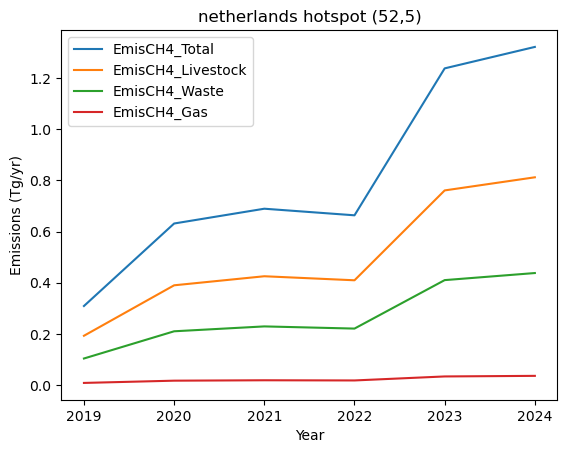

In [12]:
# Netherlands hotspot
netherlands = calc_emissions_at_gridcell(52,5)
print(netherlands)
# combine Wastewater, Landfills, OtherAnth
netherlands["EmisCH4_Waste"] = netherlands["EmisCH4_Wastewater"] + netherlands["EmisCH4_Landfills"] + netherlands["EmisCH4_OtherAnth"]

netherlands.plot(x="year", y=["EmisCH4_Total", "EmisCH4_Livestock", "EmisCH4_Waste", "EmisCH4_Gas"])
plt.title('netherlands hotspot (52,5)')
plt.xticks(netherlands["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
plt.show()

In [9]:
# CONUS total emissions
df = pd.DataFrame(columns=["year", "emissions", "livestock", "waste", "wetlands"])
mask_conus = xr.open_dataset("../shapefiles/masks/conus.nc")
mask_conus = mask_conus.rename({"__xarray_dataarray_variable__": "Mask"})
mask_conus = mask_conus["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"]+posterior_ds["EmisCH4_Landfills"]+posterior_ds["EmisCH4_OtherAnth"]
    # posterior_og = posterior_ds["EmisCH4_Oil"] + posterior_ds["EmisCH4_Gas"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_conus) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_conus) # Tg/yr
    emis_subset_waste = sum_total_emissions(posterior_waste, areas, mask_conus) # Tg/yr
    # emis_subset_og = sum_total_emissions(posterior_og, areas, mask_conus) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_conus) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_livestock, emis_subset_waste, emis_subset_wetlands]
print(df)

x = df["year"]
y = df["emissions"]
y1 = df["livestock"]
y2 = df["waste"]
y3 = df["wetlands"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in livestock emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in waste emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

print(f"Slope (annual change in wetland emissions): {slope3:.2f} Tg/yr")
print(f"P-value: {p_value3:.4f}")

     year  emissions  livestock     waste  wetlands
0  2019.0  38.203573   9.581845  6.152346  8.440342
1  2020.0  37.542549   9.983120  6.053496  7.905318
2  2021.0  41.620295  11.187414  6.685984  8.413441
3  2022.0  36.697927  10.125482  6.012923  7.584588
4  2023.0  36.237085  10.330852  5.862381  6.512616
5  2024.0  39.943780  11.895134  6.561487  7.438589
Slope (annual change in emissions): -0.00 Tg/yr
P-value: 0.9946
Slope (annual change in livestock emissions): 0.33 Tg/yr
P-value: 0.1081
Slope (annual change in waste emissions): 0.02 Tg/yr
P-value: 0.8055
Slope (annual change in wetland emissions): -0.29 Tg/yr
P-value: 0.0900


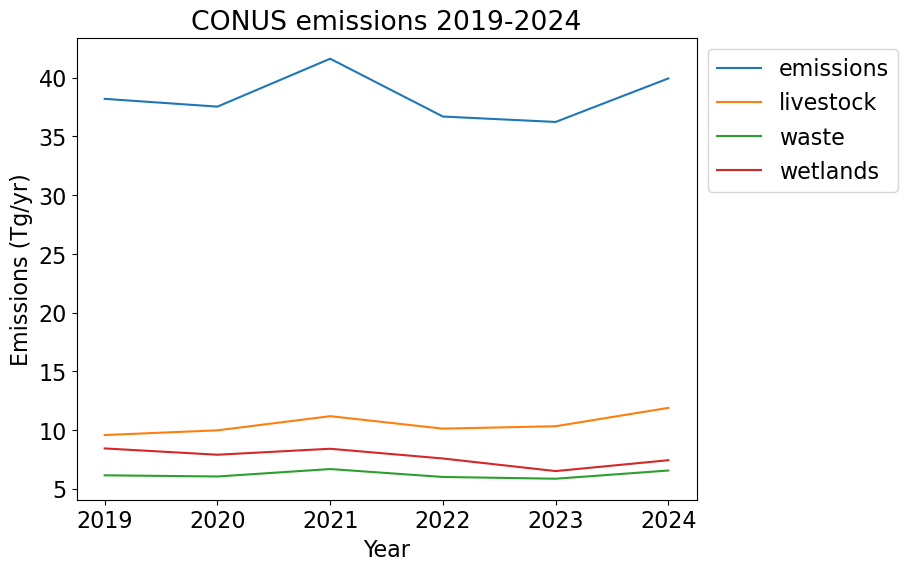

In [11]:
# plot df
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
df.plot(x="year", y=["emissions", "livestock", "waste", "wetlands"], ax=ax)
plt.xticks(df["year"])
plt.ylabel("Emissions (Tg/yr)")
plt.xlabel("Year")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('CONUS emissions 2019-2024')
plt.show()

In [12]:
# Russia total emissions
df = pd.DataFrame(columns=["year", "emissions", "livestock", "waste", "oil/gas"])
mask_russia = xr.open_dataset("../shapefiles/masks/russia.nc")
mask_russia = mask_russia.rename({"__xarray_dataarray_variable__": "Mask"})
mask_russia = mask_russia["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"]+posterior_ds["EmisCH4_Landfills"]+posterior_ds["EmisCH4_OtherAnth"]
    posterior_og = posterior_ds["EmisCH4_Oil"] + posterior_ds["EmisCH4_Gas"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_russia) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_russia) # Tg/yr
    emis_subset_waste = sum_total_emissions(posterior_waste, areas, mask_russia) # Tg/yr
    emis_subset_og = sum_total_emissions(posterior_og, areas, mask_russia) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_livestock, emis_subset_waste, emis_subset_og]
print(df)

x = df["year"]
y = df["emissions"]
y1 = df["livestock"]
y2 = df["waste"]
y3 = df["oil/gas"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in livestock emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

print(f"Slope (annual change in waste emissions): {slope2:.2f} Tg/yr")
print(f"P-value: {p_value2:.4f}")

print(f"Slope (annual change in og emissions): {slope3:.2f} Tg/yr")
print(f"P-value: {p_value3:.4f}")

     year  emissions  livestock     waste   oil/gas
0  2019.0  23.501382   1.546312  1.746593  2.634931
1  2020.0  24.921913   1.716407  2.134543  3.052718
2  2021.0  23.063151   1.726267  1.963818  2.656566
3  2022.0  21.091176   1.715609  1.452343  1.897374
4  2023.0  18.058374   1.647678  1.544838  1.399326
5  2024.0  22.325383   1.772713  2.139301  0.759250
Slope (annual change in emissions): -0.81 Tg/yr
P-value: 0.1713
Slope (annual change in livestock emissions): 0.03 Tg/yr
P-value: 0.1963
Slope (annual change in waste emissions): -0.01 Tg/yr
P-value: 0.9141
Slope (annual change in og emissions): -0.43 Tg/yr
P-value: 0.0088


In [3]:
# China coal
df = pd.DataFrame(columns=["year", "emissions", "livestock", "rice", "coal"])
mask_china = xr.open_dataset("../shapefiles/masks/china.nc")
mask_china = mask_china.rename({"__xarray_dataarray_variable__": "Mask"})
mask_china = mask_china["Mask"]
years = [2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_rice = posterior_ds["EmisCH4_Rice"]
    posterior_coal = posterior_ds["EmisCH4_Coal"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_china) # Tg/yr
    emis_subset_livestock = sum_total_emissions(posterior_livestock, areas, mask_china) # Tg/yr
    emis_subset_rice = sum_total_emissions(posterior_rice, areas, mask_china) # Tg/yr
    emis_subset_coal = sum_total_emissions(posterior_coal, areas, mask_china) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_livestock, emis_subset_rice, emis_subset_coal]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["livestock"]
y2 = df["rice"]
y3 = df["coal"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)
slope2, _, _, p_value2, _ = linregress(x, y2)
slope3, _, _, p_value3, _ = linregress(x, y3)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

     year  emissions  livestock      rice       coal
0  2019.0  52.221332   8.421785  7.404973  14.157978
1  2020.0  52.415213   8.892949  7.213387  13.404334
2  2021.0  53.067943   8.655594  7.204025  13.745280
3  2022.0  50.270070   7.981481  7.705612  12.438450
4  2023.0  53.514929   8.504044  7.707965  13.481535
5  2024.0  54.699642   8.437751  8.265453  13.642714
Slope (annual change in emissions): 0.37 Tg/yr
P-value: 0.3535
Slope (annual change in emissions): -0.05 Tg/yr
P-value: 0.5474


In [5]:
# Europe total emissions
df = pd.DataFrame(columns=["year", "emissions"])
mask_europe = xr.open_dataset("../shapefiles/masks/europe.nc")
mask_europe = mask_europe.rename({"__xarray_dataarray_variable__": "Mask"})
mask_europe = mask_europe["Mask"]
years = [2019, 2020, 2021, 2022, 2023]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_europe) # Tg/yr
    df.loc[len(df)] = [year, emis_subset]

print(df)

x = df["year"]
y = df["emissions"]
slope, _, _, p_value, _ = linregress(x, y)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

     year  emissions
0  2019.0  17.873639
1  2020.0  22.051075
2  2021.0  21.527042
3  2022.0  19.833634
4  2023.0  24.322570
Slope (annual change in emissions): 1.07 Tg/yr
P-value: 0.1909


In [8]:
# South Asia total emissions
df = pd.DataFrame(columns=["year", "emissions", "wetlands"])
mask_south_asia = xr.open_dataset("../shapefiles/masks/south-asia.nc")
mask_south_asia = mask_south_asia.rename({"__xarray_dataarray_variable__": "Mask"})
mask_south_asia = mask_south_asia["Mask"]
years = [2019, 2020, 2021, 2022, 2023]
for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]
    
    emis_subset = sum_total_emissions(posterior, areas, mask_south_asia) # Tg/yr
    emis_subset_wetlands = sum_total_emissions(posterior_wetlands, areas, mask_south_asia) # Tg/yr
    df.loc[len(df)] = [year, emis_subset, emis_subset_wetlands]

print(df)

x = df["year"]
y = df["emissions"]
y1 = df["wetlands"]
slope, _, _, p_value, _ = linregress(x, y)
slope1, _, _, p_value1, _ = linregress(x, y1)

# Print the regression results.
print(f"Slope (annual change in emissions): {slope:.2f} Tg/yr")
print(f"P-value: {p_value:.4f}")

print(f"Slope (annual change in wetland emissions): {slope1:.2f} Tg/yr")
print(f"P-value: {p_value1:.4f}")

     year  emissions   wetlands
0  2019.0  47.466100  10.014827
1  2020.0  43.586416   8.115302
2  2021.0  42.471374   7.413564
3  2022.0  41.147236   7.360363
4  2023.0  41.812423   7.088897
Slope (annual change in emissions): -1.37 Tg/yr
P-value: 0.0552
Slope (annual change in wetland emissions): -0.66 Tg/yr
P-value: 0.0499
